In [1]:
import pandas as pd

xl = pd.ExcelFile("env_wasgen$defaultview_spreadsheet.xlsx")

target_sheets = {
    'Sheet 76':  'Сільське госп-во',
    'Sheet 81':  'Видобуток корисних копалин',
    'Sheet 86':  'Переробна пром-сть',
    'Sheet 91':  'Харчова пром-сть',
    'Sheet 96':  'Текстильна пром-сть',
    'Sheet 106': 'Хімічна пром-сть',
    'Sheet 111': 'Металургія',
    'Sheet 116': 'Будівництво',
    'Sheet 121': 'Енергетика',
}

results = []
for sheet, industry in target_sheets.items():
    df = pd.read_excel(
        "env_wasgen$defaultview_spreadsheet.xlsx",
        sheet_name=sheet, skiprows=10, header=0
    )
    for country in ['Bulgaria', 'Finland']:
        row = df[df.iloc[:, 0] == country]
        if not row.empty:
            r = row.iloc[0]
            val = r.dropna().iloc[-1]
            results.append({
                'industry': industry,
                'country': country,
                'val_t': val
            })

df_eu = pd.DataFrame(results)
print(df_eu)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/con

                      industry   country     val_t
0             Сільське госп-во  Bulgaria    859984
1             Сільське госп-во   Finland         0
2   Видобуток корисних копалин  Bulgaria  70272817
3   Видобуток корисних копалин   Finland  84682163
4           Переробна пром-сть  Bulgaria   5289479
5           Переробна пром-сть   Finland  10385717
6             Харчова пром-сть  Bulgaria    310725
7             Харчова пром-сть   Finland    620257
8          Текстильна пром-сть  Bulgaria     25045
9          Текстильна пром-сть   Finland      9203
10            Хімічна пром-сть  Bulgaria  13932326
11            Хімічна пром-сть   Finland  27765995
12                  Металургія  Bulgaria    395298
13                  Металургія   Finland   1118912
14                 Будівництво  Bulgaria       631
15                 Будівництво   Finland      6297
16                  Енергетика  Bulgaria       954
17                  Енергетика   Finland       277


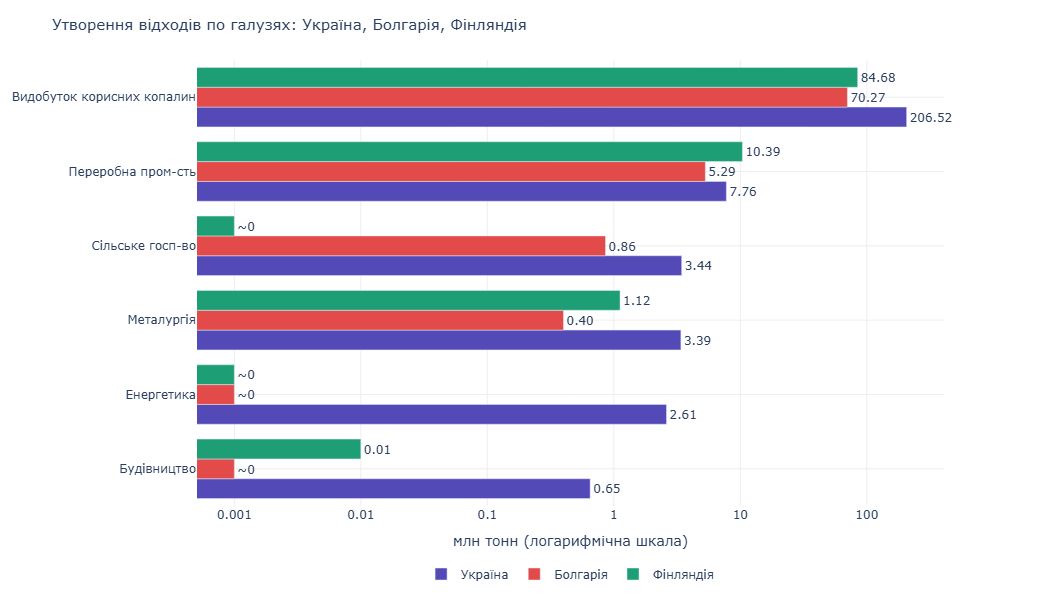

In [2]:
import pandas as pd
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# 1. (Болгарія і Фінляндія) 
target_sheets = {
    'Sheet 76':  'Сільське госп-во',
    'Sheet 81':  'Видобуток корисних копалин',
    'Sheet 86':  'Переробна пром-сть',
    'Sheet 111': 'Металургія',
    'Sheet 116': 'Будівництво',
    'Sheet 121': 'Енергетика',
}

eu_results = []
for sheet, industry in target_sheets.items():
    df = pd.read_excel("env_wasgen$defaultview_spreadsheet.xlsx",
                       sheet_name=sheet, skiprows=10, header=0)
    for country in ['Bulgaria', 'Finland']:
        row = df[df.iloc[:, 0] == country]
        if not row.empty:
            numeric = pd.to_numeric(row.iloc[0, 1:], errors='coerce').dropna()
            val = numeric.iloc[-1] if not numeric.empty else 0
            eu_results.append({
                'industry': industry,
                'country': 'Болгарія' if country == 'Bulgaria' else 'Фінляндія',
                'val_m': round(val / 1e6, 2)
            })

df_eu = pd.DataFrame(eu_results)

#  2. ДАНІ УКРАЇНИ з waste_cleaned.csv 
df_ua = pd.read_csv("waste_cleaned.csv")
year_cols = ['2015','2016','2017','2018','2019','2020','2021','2022','2023','2024']

def latest(row):
    for y in reversed(year_cols):
        v = row[y]
        if pd.notna(v) and v > 0:
            return v
    return 0

df_kved = df_ua[
    (df_ua['region'] == 'Україна') &
    (df_ua['category'] == 'За видами КВЕД') &
    (df_ua['hazard_class'] == 'I-IV. Відходи в цілому')
].copy()
df_kved['val'] = df_kved.apply(latest, axis=1)

# Mapping українських галузей → спільні назви
ua_map = {
    'Сільське господарство, лісове господарство та рибне господарство': 'Сільське госп-во',
    'Добування металевих руд':                                           'Видобуток корисних копалин',
    'Переробна промисловість':                                           'Переробна пром-сть',
    'Металургійне виробництво':                                          'Металургія',
    'Будівництво':                                                       'Будівництво',
    'Постачання електроенергії, газу, пари та кондиційованого повітря':  'Енергетика',
}

ua_results = []
for full_name, short_name in ua_map.items():
    row = df_kved[df_kved['subcategory'] == full_name]
    if not row.empty:
        val = row.iloc[0]['val']
        ua_results.append({
            'industry': short_name,
            'country': 'Україна',
            'val_m': round(val / 1e6, 2)
        })

df_ukraine = pd.DataFrame(ua_results)

#  3. ОБ'ЄДНУЄМО 
df_all = pd.concat([df_ukraine, df_eu], ignore_index=True)

# Сортуємо галузі по значенню України
industry_order = (df_all[df_all['country'] == 'Україна']
                  .sort_values('val_m', ascending=True)['industry'].tolist())

# ── 4. ГРАФІК ───────────────────────────────────────────────────
# Кольори: синій для України, зелений для Фінляндії, червоний для Болгарії
colors = {
    'Україна':   '#534AB7',
    'Болгарія':  '#E24B4A',
    'Фінляндія': '#1D9E75',
}

fig = go.Figure()

MIN_VAL = 0.001  # мінімальне видиме значення на log шкалі

for country, color in colors.items():
    df_c = df_all[df_all['country'] == country].set_index('industry')
    vals = []
    labels = []
    for ind in industry_order:
        v = df_c.loc[ind, 'val_m'] if ind in df_c.index else 0
        if v < MIN_VAL:
            vals.append(MIN_VAL)
            labels.append('~0')
        else:
            vals.append(v)
            labels.append(f"{v:.2f}")

    fig.add_trace(go.Bar(
        name=country,
        x=vals,
        y=industry_order,
        orientation='h',
        marker_color=color,
        text=labels,
        textposition='outside',
        cliponaxis=False,
        hovertemplate=f"{country}: %{{x:.2f}} млн т<extra></extra>",
    ))

fig.update_layout(
    title=dict(text='Утворення відходів по галузях: Україна, Болгарія, Фінляндія', font=dict(size=15)),
    barmode='group',
    height=600,
    margin=dict(l=20, r=100, t=60, b=80),
    legend=dict(orientation='h', y=-0.12, x=0.3),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        title='млн тонн (логарифмічна шкала)',
        type='log',
        gridcolor='#eeeeee',
        tickvals=[0.001, 0.01, 0.1, 1, 10, 100],
        ticktext=['0.001', '0.01', '0.1', '1', '10', '100'],
    ),
    yaxis=dict(gridcolor='#eeeeee'),
)

fig.show()

In [3]:
import pandas as pd

countries_eu = [
    'Італія','Бельгія','Словаччина','Латвія','Нідерланди','Австрія','Данія',
    'Люксембург','Швеція','Німеччина','Франція','Чехія','Словенія','Естонія',
    'Литва','Угорщина','Іспанія','Польща','Португалія','Хорватія','Ірландія',
    'Кіпр','Греція','Мальта','Фінляндія','Болгарія','Румунія'
]

recycling_eu = [85.6,68.3,68.3,65,62,60,56,54,52,50,47,45,43,42,40,38,36,34,32,30,28,18,16,15,14,4,3]
energy_eu    = [5,18,10,8,25,30,38,40,44,40,35,40,42,50,42,40,32,20,28,18,50,2,2,2,5,2,1]
landfill_eu  = [6,10,18,20,10,8,4,4,2,8,15,12,12,6,15,18,28,40,36,48,20,75,75,78,81,88,93]
other_eu     = [3.4,3.7,3.7,7,3,2,2,2,2,2,3,3,3,2,3,4,4,6,4,4,2,5,7,5,0,6,3]

df_eu = pd.DataFrame({
    'country':   countries_eu,
    'recycling': recycling_eu,
    'energy':    energy_eu,
    'landfill':  landfill_eu,
    'other':     other_eu,
    'source':    'Eurostat 2022'
})

print(df_eu.shape)
print(df_eu.head())

(27, 6)
      country  recycling  energy  landfill  other         source
0      Італія       85.6       5         6    3.4  Eurostat 2022
1     Бельгія       68.3      18        10    3.7  Eurostat 2022
2  Словаччина       68.3      10        18    3.7  Eurostat 2022
3      Латвія       65.0       8        20    7.0  Eurostat 2022
4  Нідерланди       62.0      25        10    3.0  Eurostat 2022


In [4]:
df_ua_chart = pd.DataFrame({
    'country':   ['Україна *'],
    'recycling': [22.0],
    'energy':    [1.0],
    'landfill':  [40.0],
    'other':     [37.0],
    'source':    'Держстат 2020'
})

print(df_ua_chart)

     country  recycling  energy  landfill  other         source
0  Україна *       22.0     1.0      40.0   37.0  Держстат 2020


In [5]:
# З'єднуємо  датасети
df_combined = pd.concat([df_eu, df_ua_chart], ignore_index=True)

# Сортуємо по захороненню 
df_sorted = df_combined.sort_values('landfill', ascending=True).reset_index(drop=True)

print(f"Всього країн: {len(df_sorted)}")
print(df_sorted[['country', 'landfill']].to_string())

Всього країн: 28
       country  landfill
0       Швеція       2.0
1        Данія       4.0
2   Люксембург       4.0
3       Італія       6.0
4      Естонія       6.0
5    Німеччина       8.0
6      Австрія       8.0
7      Бельгія      10.0
8   Нідерланди      10.0
9        Чехія      12.0
10    Словенія      12.0
11     Франція      15.0
12       Литва      15.0
13  Словаччина      18.0
14    Угорщина      18.0
15      Латвія      20.0
16    Ірландія      20.0
17     Іспанія      28.0
18  Португалія      36.0
19      Польща      40.0
20   Україна *      40.0
21    Хорватія      48.0
22      Греція      75.0
23        Кіпр      75.0
24      Мальта      78.0
25   Фінляндія      81.0
26    Болгарія      88.0
27     Румунія      93.0


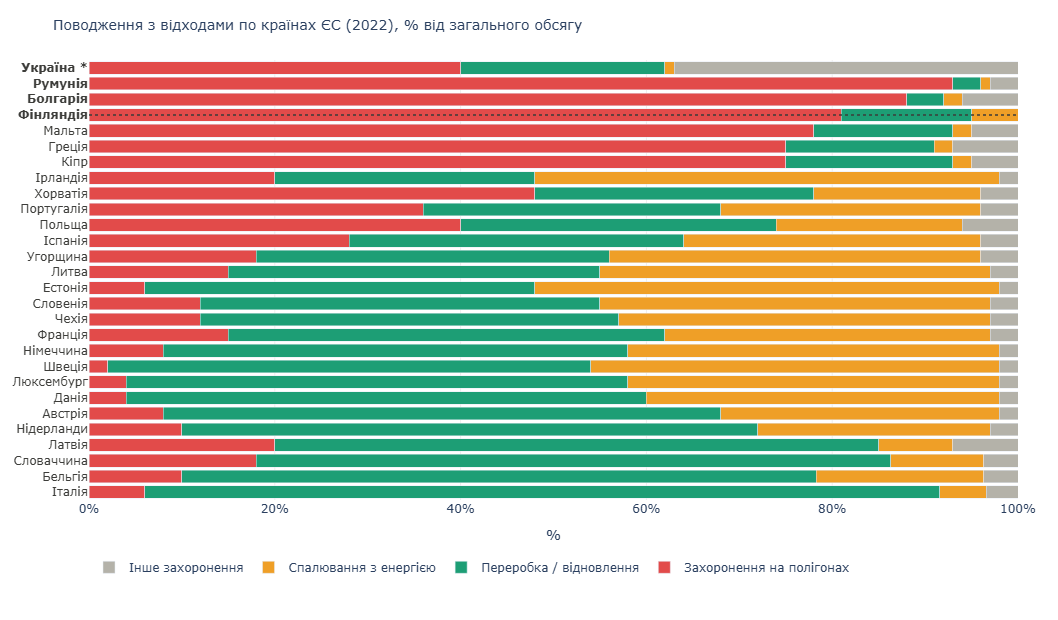

In [6]:
import plotly.graph_objects as go

countries = [
    'Італія','Бельгія','Словаччина','Латвія','Нідерланди','Австрія','Данія',
    'Люксембург','Швеція','Німеччина','Франція','Чехія','Словенія','Естонія',
    'Литва','Угорщина','Іспанія','Польща','Португалія','Хорватія','Ірландія',
    'Кіпр','Греція','Мальта','Фінляндія','Болгарія','Румунія',
    'Україна *'
]

recycling = [85.6,68.3,68.3,65,62,60,56,54,52,50,47,45,43,42,40,38,36,34,32,30,28,18,16,15,14,4,3,22]
energy    = [5,18,10,8,25,30,38,40,44,40,35,40,42,50,42,40,32,20,28,18,50,2,2,2,5,2,1,1]
landfill  = [6,10,18,20,10,8,4,4,2,8,15,12,12,6,15,18,28,40,36,48,20,75,75,78,81,88,93,40]
other     = [3.4,3.7,3.7,7,3,2,2,2,2,2,3,3,3,2,3,4,4,6,4,4,2,5,7,5,0,6,3,37]

colors = {
    'Переробка / відновлення':    '#1D9E75',
    'Спалювання з енергією':      '#EF9F27',
    'Захоронення на полігонах':   '#E24B4A',
    'Інше захоронення':           '#B4B2A9',
}

datasets = [
    ('Захоронення на полігонах', landfill,  '#E24B4A'),
    ('Переробка / відновлення',  recycling, '#1D9E75'),
    ('Спалювання з енергією',    energy,    '#EF9F27'),
    ('Інше захоронення',         other,     '#B4B2A9')
]

# Кольори підписів —Україна і Болгарія
label_colors = []
for c in countries:
    if c == 'Україна *':
        label_colors.append('#534AB7')
    elif c in ['Болгарія', 'Румунія']:
        label_colors.append('#A32D2D')
    elif c == 'Фінляндія':
        label_colors.append('#BA7517')
    else:
        label_colors.append('#3d3d3a')

fig = go.Figure()

for name, data, color in datasets:
    fig.add_trace(go.Bar(
        name=name,
        y=countries,
        x=data,
        orientation='h',
        marker_color=color,
        hovertemplate=f'{name}: %{{x:.1f}}%<extra></extra>',
    ))

fig.update_layout(
    title=dict(
        text='Поводження з відходами по країнах ЄС (2022), % від загального обсягу',
        font=dict(size=14)
    ),
    barmode='stack',
    height=620,
    width=720,
    margin=dict(l=20, r=40, t=60, b=120),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        title='%',
        range=[0, 100],
        ticksuffix='%',
        gridcolor='#eeeeee',
    ),
    yaxis=dict(
        gridcolor='#eeeeee',
        tickfont=dict(color='#3d3d3a'),
    ),
    legend=dict(orientation='h', y=-0.12),
    shapes=[dict(
        type='line', xref='paper', yref='y',
        x0=0, x1=1,
        y0='Фінляндія', y1='Фінляндія',
        line=dict(color='#3d3d3a', width=1.5, dash='dot')
    )]
)
# Виділяю
fig.update_yaxes(
    ticktext=[
        f'<b>{c}</b>' if c in ['Україна *', 'Болгарія', 'Румунія', 'Фінляндія']
        else c
        for c in countries
    ],
    tickvals=countries,
)

fig.show()